In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv("C:/Users/HP/code/data/cookie_cats.csv")

In [3]:
df.head

<bound method NDFrame.head of         userid  version  sum_gamerounds  retention_1  retention_7
0          116  gate_30               3        False        False
1          337  gate_30              38         True        False
2          377  gate_40             165         True        False
3          483  gate_40               1        False        False
4          488  gate_40             179         True         True
...        ...      ...             ...          ...          ...
90184  9999441  gate_40              97         True        False
90185  9999479  gate_40              30        False        False
90186  9999710  gate_30              28         True        False
90187  9999768  gate_40              51         True        False
90188  9999861  gate_40              16        False        False

[90189 rows x 5 columns]>

In [4]:
df.shape

(90189, 5)

In [5]:
print("\n分组数量统计：")
print(df["version"].value_counts())


分组数量统计：
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


In [6]:
print(df["version"].value_counts())

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


In [7]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
import scipy.stats as stats

In [10]:
X = ['sum_gamerounds']

In [11]:
descriptive_stats = df[X].describe().T

In [12]:
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
sum_gamerounds,90189.0,51.872457,195.050858,0.0,5.0,16.0,51.0,49854.0


In [13]:
skewness = df[X].skew().rename('skewness')

In [14]:
kurtosis = df[X].kurtosis().rename('kurtosis')

In [15]:
skewness

sum_gamerounds    185.436313
Name: skewness, dtype: float64

In [16]:
kurtosis

sum_gamerounds    47130.369631
Name: kurtosis, dtype: float64

In [17]:
concatenated_control = pd.concat([
    descriptive_stats,
    skewness,
    kurtosis
], axis=1)

In [18]:
concatenated_control

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
sum_gamerounds,90189.0,51.872457,195.050858,0.0,5.0,16.0,51.0,49854.0,185.436313,47130.369631


In [19]:
# Compute confidence intervals
confidence_level = 0.95  # 设置置信水平95%
values = df[X].dropna()  # 删除缺失值，只保留有效样本
mean = values.mean()     # 样本均值
std_error = stats.sem(values) # 标准误 = 样本标准差 / sqrt(n)


In [20]:
if std_error != 0:
    # Compute the t-distribution confidence intervals
    lower, upper = stats.t.interval(confidence_level, len(values) - 1, loc=mean, scale=std_error)
else:
    lower, upper = mean, mean


In [21]:
# Add confidence intervals to the DataFrame
concatenated_control['lower_ci'] = lower
concatenated_control['upper_ci'] = upper

# Display the results
print(concatenated_control)

                  count       mean         std  min  25%   50%   75%      max  \
sum_gamerounds  90189.0  51.872457  195.050858  0.0  5.0  16.0  51.0  49854.0   

                  skewness      kurtosis   lower_ci   upper_ci  
sum_gamerounds  185.436313  47130.369631  50.599467  53.145447  


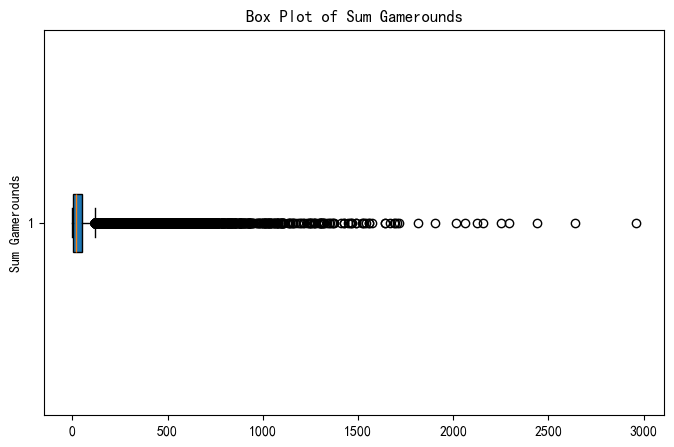

In [75]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['sum_gamerounds'], 
            vert=False,
           patch_artist=True
           )
plt.title('Box Plot of Sum Gamerounds')
plt.ylabel('Sum Gamerounds')
plt.savefig("D:/桌面/Box plot of Sum Gamerrounds.", dpi=300, bbox_inches="tight")
plt.show()


In [23]:
import matplotlib.font_manager as fm
font_list = [f.name for f in fm.fontManager.ttflist]
for name in font_list:
    if 'CJK' in name or 'Hei' in name or 'Sim' in name:
        print(name)


Microsoft JhengHei
Microsoft JhengHei
Microsoft YaHei
Microsoft YaHei
Microsoft YaHei
SimHei
Microsoft JhengHei
SimSun-ExtB
SimSun


In [24]:
max_value = df['sum_gamerounds'].max()

In [25]:
max_value

49854

In [26]:
df = df[df['sum_gamerounds'] != max_value]

In [27]:
df.reset_index(drop=True, inplace=True)

In [28]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [31]:
pivot_table = df.pivot_table(
    values='sum_gamerounds',
    index='version',
    aggfunc='mean'
)
print(pivot_table)

         sum_gamerounds
version                
gate_30       51.342111
gate_40       51.298776


In [33]:
df['log_sum_gamerounds'] = np.log1p(df['sum_gamerounds'])

C:\Users\HP\AppData\Local\Temp\ipykernel_13536\3945073682.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_sum_gamerounds'] = np.log1p(df['sum_gamerounds'])


In [34]:
df.head

<bound method NDFrame.head of         userid  version  sum_gamerounds  retention_1  retention_7  \
0          116  gate_30               3        False        False   
1          337  gate_30              38         True        False   
2          377  gate_40             165         True        False   
3          483  gate_40               1        False        False   
4          488  gate_40             179         True         True   
...        ...      ...             ...          ...          ...   
90183  9999441  gate_40              97         True        False   
90184  9999479  gate_40              30        False        False   
90185  9999710  gate_30              28         True        False   
90186  9999768  gate_40              51         True        False   
90187  9999861  gate_40              16        False        False   

       log_sum_gamerounds  
0                1.386294  
1                3.663562  
2                5.111988  
3                0.693147  
4

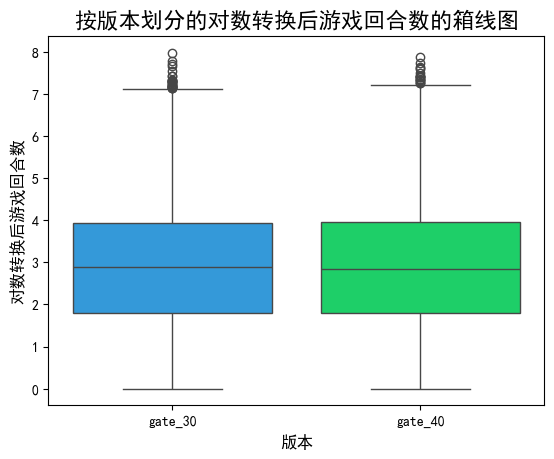

In [76]:
# 创建一个箱线图以对数化的游戏进度
sns.boxplot(data=df, x='version', y='log_sum_gamerounds',
            hue='version',
            palette=['#199FF4','#01EC63'] )

plt.title('按版本划分的对数转换后游戏回合数的箱线图', fontsize=16)
plt.xlabel('版本', fontsize=12)
plt.ylabel('对数转换后游戏回合数', fontsize=12)

# Display the plot
plt.savefig("D:/桌面/对数化箱线图.", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
df_test= df[df['version']=='gate_40']
df_control= df[df['version']=='gate_30']

In [40]:
import pandas as pd
from scipy.stats import norm

alpha = 0.05    # I类错误，显著性水平
beta = 0.2      # II类错误；统计功效 power = 1-beta = 0.8

# 计算Z：Zα/2 + Zβ
Z = (norm.ppf(1-(alpha/2), loc=0, scale=1) + norm.ppf(1-beta, loc=0, scale=1))**2

# 合并两组数据，计算总体方差
var = pd.concat([df_control['sum_gamerounds'], df_test['sum_gamerounds']]).var()

expected_effect_size = 5   # 预期效应量：两组均值差值=5

# 样本量公式
sample_size = (Z*2*var)/(expected_effect_size**2)

print(sample_size.astype('int'))


6620


In [41]:
def choose_random_sample(data):
    return data.sample(n=int(sample_size), random_state=42)

# 直接抽样
df_control_smpl = choose_random_sample(df_control)
df_test_smpl = choose_random_sample(df_test)

print(df_control_smpl)
print(df_test_smpl)


        userid  version  sum_gamerounds  retention_1  retention_7  \
58980  6531088  gate_30              55         True        False   
72247  8003089  gate_30               2        False        False   
50215  5566807  gate_30              23         True        False   
609      64235  gate_30               1        False        False   
56038  6210551  gate_30               7        False        False   
...        ...      ...             ...          ...          ...   
48336  5360248  gate_30               0        False        False   
19558  2177537  gate_30               9        False        False   
32381  3601437  gate_30               2         True        False   
30133  3356288  gate_30              71        False        False   
63008  6982177  gate_30               1        False        False   

       log_sum_gamerounds  
58980            4.025352  
72247            1.098612  
50215            3.178054  
609              0.693147  
56038            2.079442  
...

In [43]:
df_control_smpl['log_sum_gamerounds'] = np.log1p(df_control_smpl['sum_gamerounds'])
df_test_smpl['log_sum_gamerounds'] = np.log1p(df_test_smpl['sum_gamerounds'])

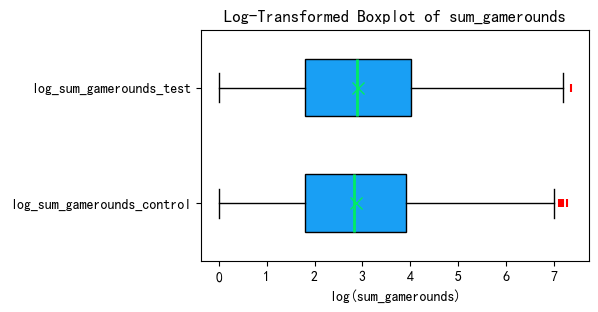

In [77]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 3))
ax.boxplot(
    x=[df_control_smpl['log_sum_gamerounds'], df_test_smpl['log_sum_gamerounds']],
    vert=False,
    patch_artist=True,
    widths=0.5,
    flierprops={
        "marker": "|",
        "markeredgecolor": "red",
        "markeredgewidth": 1.5, # 线条粗细，调大更容易看见红色
        "markerfacecolor": "red"
    },
    showmeans=True,
    showfliers=True,
    boxprops=dict(facecolor='#199FF4'),
    medianprops=dict(color='#01EC63', linewidth=2),
    meanprops=dict(marker='x', markerfacecolor='red', markeredgecolor='#01EC63', markersize=8)
)
ax.set_yticklabels(['log_sum_gamerounds_control', 'log_sum_gamerounds_test'])
ax.set_xlabel('log(sum_gamerounds)')
plt.title('Log-Transformed Boxplot of sum_gamerounds')
plt.savefig("D:/桌面/Log-boxplot of sum_gamerounds.", dpi=300, bbox_inches="tight")
plt.show()


In [54]:
import pandas as pd
from scipy.stats import levene, ttest_ind, t
import numpy as np

In [55]:
df_control_smpl

,userid,version,sum_gamerounds,retention_1,retention_7,log_sum_gamerounds
58980,6531088,gate_30,55,True,False,4.025352
72247,8003089,gate_30,2,False,False,1.098612
50215,5566807,gate_30,23,True,False,3.178054
609,64235,gate_30,1,False,False,0.693147
56038,6210551,gate_30,7,False,False,2.079442
...,...,...,...,...,...,...
48336,5360248,gate_30,0,False,False,0.000000
19558,2177537,gate_30,9,False,False,2.302585
32381,3601437,gate_30,2,True,False,1.098612
30133,3356288,gate_30,71,False,False,4.276666


In [56]:
#分组计算均值
mean_control = df_control_smpl['sum_gamerounds'].mean()
mean_test = df_test_smpl['sum_gamerounds'].mean()

print("mean_control =", mean_control)
print("mean_test =", mean_test)

mean_control = 50.778549848942596
mean_test = 51.745166163141995


In [57]:
groupC = df_control['sum_gamerounds']
groupT = df_test['sum_gamerounds']

In [59]:
statistic, p_value_L = levene(groupC, groupT)

In [60]:
statistic, p_value_L

(np.float64(0.07510153837481241), np.float64(0.7840494387892463))

In [61]:
if p_value_L > 0.05:
    # If variances are equal
    t_statistic, p_value = ttest_ind(groupC, groupT, alternative="less", equal_var=True)
else:
    # If variances are not equal
    t_statistic, p_value = ttest_ind(groupC, groupT, alternative="less", equal_var=False)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 0.0633675766982082
p-value: 0.5252630270872


In [62]:
alpha = 0.05
if p_value < alpha:
    print("拒绝原假设：两个均值之间存在显著差异。")
else:
    print("无法拒绝原假设：两个均值之间不存在显著差异。")

无法拒绝原假设：两个均值之间不存在显著差异。


In [63]:
#计算均值差
mean_difference =  mean_test-mean_control 
print("Mean difference =", mean_difference)

std_control = df_control_smpl['sum_gamerounds'].std()
std_test = df_test_smpl['sum_gamerounds'].std()


Mean difference = 0.9666163141993991


In [64]:
n_control = len(groupC)
n_test = len(groupT)


In [66]:
n_control,n_test

(44699, 45489)

In [67]:
SE = np.sqrt((std_control**2 / n_control) + (std_test**2 / n_test))

In [68]:
ddf = n_control + n_test - 2

In [69]:
t_critical = t.ppf(1 - 0.025, ddf)

In [70]:
margin_of_error = t_critical * SE
confidence_interval = (mean_difference - margin_of_error, mean_difference + margin_of_error)

In [71]:
SE ,ddf,t_critical,margin_of_error,confidence_interval

(np.float64(0.66284958123048),
 90186,
 np.float64(1.9599902890942755),
 np.float64(1.2991787423419479),
 (np.float64(-0.33256242814254877), np.float64(2.265795056541347)))

In [72]:
print("置信区间:", confidence_interval)

置信区间: (np.float64(-0.33256242814254877), np.float64(2.265795056541347))


In [79]:
# 1. 分组统计7日留存数量
retention7_table = pd.crosstab(df['version'], df['retention_7'])
print("7日留存列联表：")
print(retention7_table)

7日留存列联表：
retention_7  False  True 
version                  
gate_30      36198   8501
gate_40      37210   8279


In [80]:
retention7_rate = df.groupby('version')['retention_7'].mean()
print("\n各组7日留存率：")
print(retention7_rate)


各组7日留存率：
version
gate_30    0.190183
gate_40    0.182000
Name: retention_7, dtype: float64


In [81]:
# 2. 卡方独立性检验
from scipy.stats import chi2_contingency
chi2_stat, p_chi2, dof, expected = chi2_contingency(retention7_table)
print(f"\n卡方统计量: {chi2_stat:.4f}")
print(f"卡方检验p值: {p_chi2:.4f}")
print(f"自由度: {dof}")
alpha = 0.05
if p_chi2 < alpha:
    print("拒绝原假设：两组7日留存率存在显著差异")
else:
    print("无法拒绝原假设：两组7日留存率不存在显著差异")


卡方统计量: 9.9153
卡方检验p值: 0.0016
自由度: 1
拒绝原假设：两组7日留存率存在显著差异


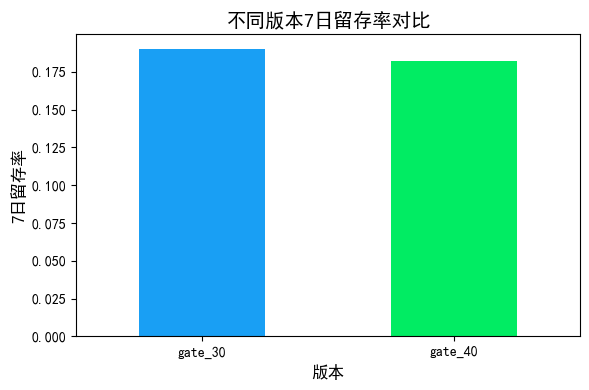

In [82]:
plt.figure(figsize=(6,4))
retention7_rate.plot(kind='bar', color=['#199FF4','#01EC63'])
plt.title('不同版本7日留存率对比', fontsize=14)
plt.xlabel('版本', fontsize=12)
plt.ylabel('7日留存率', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()